In [2]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.5 MB/s eta 0:00:00



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        29
           1       0.00      0.00      0.00         2

    accuracy                           0.94        31
   macro avg       0.47      0.50      0.48        31
weighted avg       0.88      0.94      0.90        31

Confusion Matrix:
 [[29  0]
 [ 2  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Gradient Boosting (XGBoost) ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.50      0.67         2

    accuracy                           0.97        31
   macro avg       0.98      0.75      0.82        31
weighted avg       0.97      0.97      0.96        31

Confusion Matrix:
 [[29  0]
 [ 1  1]]

=== Hidden Markov Model (HMM) ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       115
           1       0.00      0.00      0.00         7

    accuracy                           0.94       122
   macro avg       0.47      0.50      0.49       122
weighted avg       0.89      0.94      0.91       122

Confusion Matrix:
 [[115   0]
 [  7   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


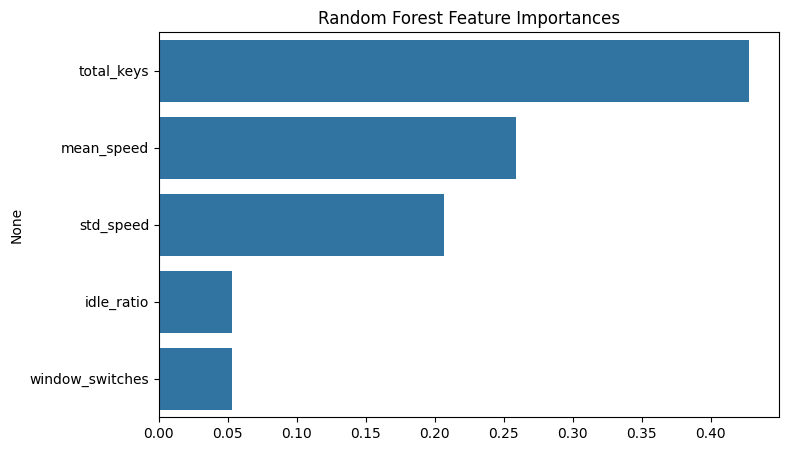

In [3]:
# ==============================
# Focus vs. Distracted Classifier
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load engineered features ---
df = pd.read_csv("/content/engineered_keystroke_features.csv", index_col=0)

# Features + labels
X = df.drop(columns=['dominant_window','label'])
y = df['label']

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ========================================
# 1. Random Forest
# ========================================
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

# ========================================
# 2. Gradient Boosting (XGBoost)
# ========================================
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / max(1,len(y_train[y_train==1]))
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("\n=== Gradient Boosting (XGBoost) ===")
print(classification_report(y_test, xgb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_preds))

# ========================================
# 3. Hidden Markov Model (HMM)
# ========================================
# HMM expects sequences, so we use the chronological order of windows
# We'll train with 2 hidden states (Focused / Distracted)
X_seq = X.values
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=200, random_state=42)
model_hmm.fit(X_seq)

# Predict hidden states for the sequence
hidden_states = model_hmm.predict(X_seq)

# Map hidden states to labels (choose mapping that maximizes alignment with y)
state_means = [np.mean(y[hidden_states==i]) for i in range(2)]
mapping = {i:(1 if state_means[i] > 0.5 else 0) for i in range(2)}
hmm_preds = np.array([mapping[s] for s in hidden_states])

print("\n=== Hidden Markov Model (HMM) ===")
print(classification_report(y, hmm_preds))
print("Confusion Matrix:\n", confusion_matrix(y, hmm_preds))

# ========================================
# Feature importance visualization (for RF/XGB)
# ========================================
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importances")
plt.show()


                 minute  focus_score  true_label
2   2025-08-21 00:29:00     0.012017           0
8   2025-08-21 00:30:00     0.008723           0
6   2025-08-21 00:42:00     0.008723           0
17  2025-08-21 00:43:00     0.081625           1
30  2025-08-21 00:49:00     0.009429           0
22  2025-08-21 00:50:00     0.008723           0
12  2025-08-21 00:52:00     0.026788           0
7   2025-08-21 00:59:00     0.055885           0
24  2025-08-21 01:02:00     0.004662           0
3   2025-08-21 01:07:00     0.004662           0

ROC-AUC (probabilistic performance): 0.983


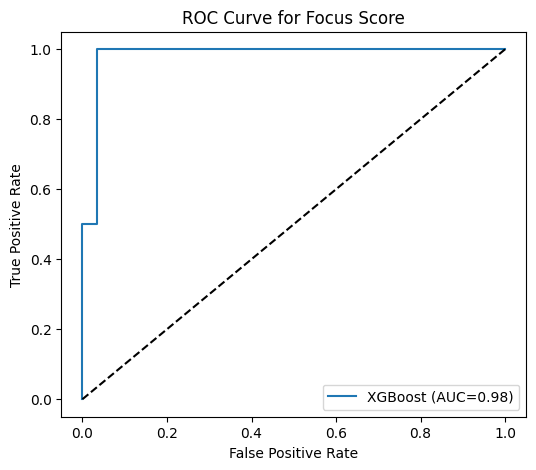

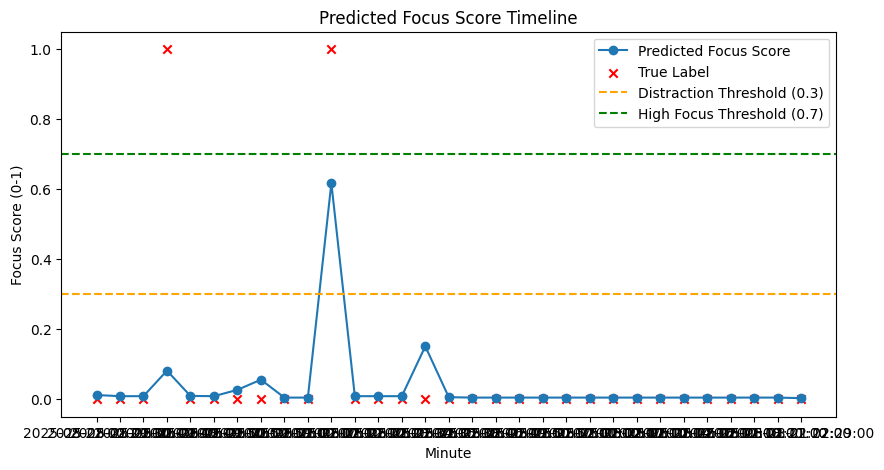

In [4]:
# ==============================
# Focus Score (Probabilistic Approach)
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# --- Load engineered features ---
df = pd.read_csv("engineered_keystroke_features.csv", index_col=0)

# Features + labels
X = df.drop(columns=['dominant_window','label'])
y = df['label']

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ========================================
# Train Gradient Boosting (XGBoost) for focus score
# ========================================
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / max(1, len(y_train[y_train==1]))
)
xgb.fit(X_train, y_train)

# --- Probabilistic predictions ---
focus_scores = xgb.predict_proba(X_test)[:,1]  # probability of "focused"

results = pd.DataFrame({
    "minute": X_test.index,
    "focus_score": focus_scores,
    "true_label": y_test.values
}).sort_values("minute")

print(results.head(10))

# --- Evaluate with ROC-AUC ---
auc = roc_auc_score(y_test, focus_scores)
print(f"\nROC-AUC (probabilistic performance): {auc:.3f}")

# --- Plot ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, focus_scores)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC={auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Focus Score")
plt.legend()
plt.show()

# --- Plot focus score timeline ---
plt.figure(figsize=(10,5))
plt.plot(results["minute"], results["focus_score"], marker="o", label="Predicted Focus Score")
plt.scatter(results["minute"], results["true_label"], color="red", marker="x", label="True Label")
plt.axhline(0.3, color="orange", linestyle="--", label="Distraction Threshold (0.3)")
plt.axhline(0.7, color="green", linestyle="--", label="High Focus Threshold (0.7)")
plt.ylabel("Focus Score (0-1)")
plt.xlabel("Minute")
plt.legend()
plt.title("Predicted Focus Score Timeline")
plt.show()
